# data analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import accuracy_score, r2_score

In [2]:
data = pd.read_csv("student.csv")

## DISPLAY FIRST (5) RECORDS


In [3]:
data.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade,GPA,academic_class,continuation_status,dropout_risk,graduation_probability,recommendation
0,1,18.5,95.6,3.8,97.9,A,4.5,First Class / Super,Continue Studies,Low,95,Maintain performance
1,2,14.0,80.0,2.5,83.9,B,3.8,Upper Second,Continue Studies,Low,80,Maintain performance
2,3,19.5,86.3,5.3,100.0,A,4.5,First Class / Super,Continue Studies,Low,95,Maintain performance
3,4,25.7,70.2,7.0,100.0,A,4.5,First Class / Super,Continue Studies,Low,95,Maintain performance
4,5,13.4,81.9,6.9,92.0,A,4.5,First Class / Super,Continue Studies,Low,95,Maintain performance


## INFOMATION ABOUT DATA

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  str    
 6   GPA                      1000000 non-null  float64
 7   academic_class           1000000 non-null  str    
 8   continuation_status      1000000 non-null  str    
 9   dropout_risk             1000000 non-null  str    
 10  graduation_probability   1000000 non-null  int64  
 11  recommendation           1000000 non-null  str    
dtypes: float64(5), int64(2), str(5)
memory usage: 91.6 MB


### MISSING VALUE CHECK

In [5]:
print(data.isnull().sum())

student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
GPA                        0
academic_class             0
continuation_status        0
dropout_risk               0
graduation_probability     0
recommendation             0
dtype: int64


### STATISTICAL SUMMARY

In [6]:
data.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,GPA,graduation_probability
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,15.029127,84.711046,5.985203,84.283845,3.988701,87.050520
std,288675.278932,6.899431,9.424143,1.956421,15.432969,0.676875,10.212613
min,1.000000,0.000000,50.000000,0.000000,9.400000,1.500000,35.000000
25%,250000.750000,10.300000,78.300000,4.700000,73.900000,3.800000,80.000000
50%,500000.500000,15.000000,85.000000,6.000000,87.500000,4.500000,95.000000
75%,750000.250000,19.700000,91.800000,7.300000,100.000000,4.500000,95.000000
max,1000000.000000,40.000000,100.000000,10.000000,100.000000,4.500000,95.000000


# DATA VISUALIZATION

### GRADE DISTRIBUTION

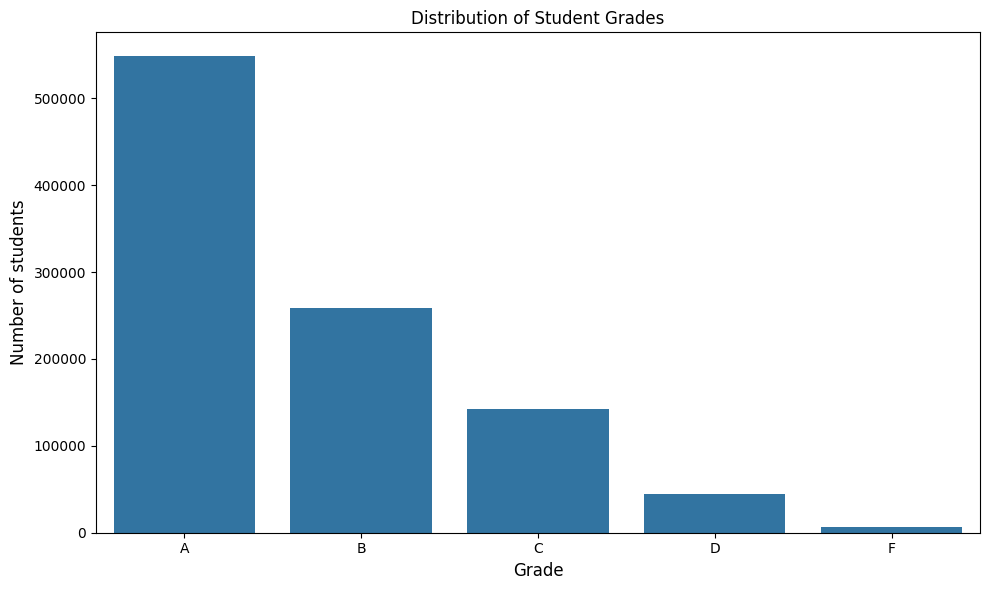

In [7]:
plt.figure(figsize=(10 ,6))
sns.countplot(data=data, x="grade", order=sorted(data["grade"].unique()))
plt.title("Distribution of Student Grades")
plt.xlabel("Grade", fontsize=12)
plt.ylabel("Number of students", fontsize=12)
plt.tight_layout()

plt.show()



### ATTENDANCE Vs TOTAL SCORE

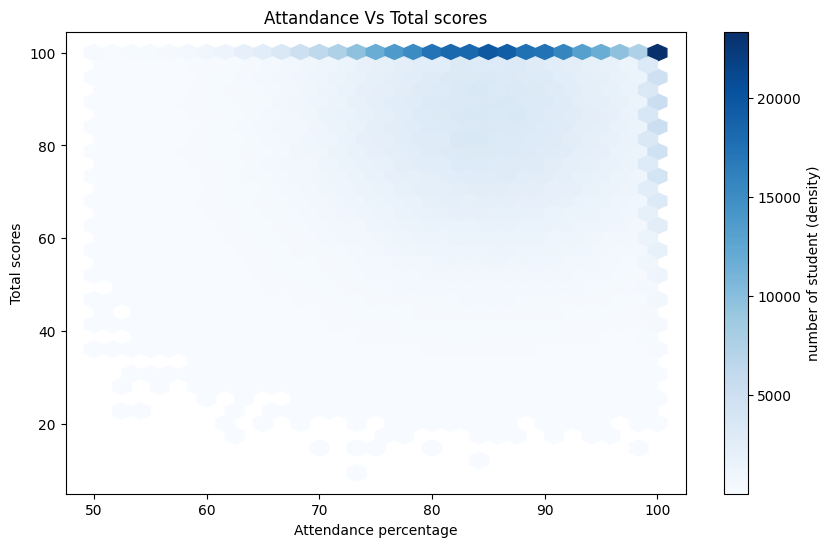

In [8]:
plt.figure(figsize=(10, 6))
plt.hexbin( data=data, x='attendance_percentage', y='total_score', gridsize=30, cmap='Blues', mincnt=1, alpha=1)
cb = plt.colorbar()
cb.set_label('number of student (density)')
plt.title("Attandance Vs Total scores")
plt.xlabel("Attendance percentage")
plt.ylabel("Total scores")
plt.show()

### STUDY HOURS Vs TOTAL SCORE

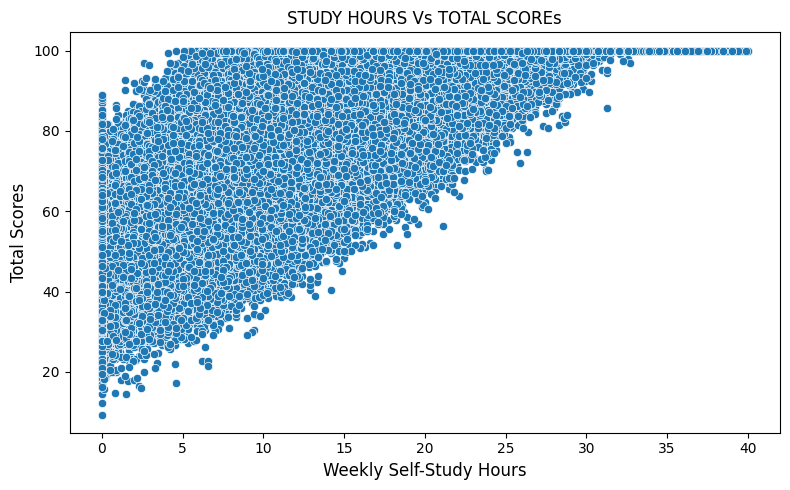

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='weekly_self_study_hours', y='total_score',)
plt.title("STUDY HOURS Vs TOTAL SCOREs")
plt.xlabel("Weekly Self-Study Hours", fontsize=12)
plt.ylabel("Total Scores", fontsize=12)
plt.tight_layout()

plt.show()

### CORRELATION MATRIX ANALYSIS

In [10]:
data.corr(numeric_only=True).round(4)

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,GPA,graduation_probability
student_id,1.0000,-0.0016,-0.0004,0.0013,-0.0005,-0.0003,0.0005
weekly_self_study_hours,-0.0016,1.0000,-0.0010,0.0012,0.8122,0.7400,0.7051
attendance_percentage,-0.0004,-0.0010,1.0000,-0.0000,-0.0010,-0.0010,-0.0010
class_participation,0.0013,0.0012,-0.0000,1.0000,0.0007,0.0009,0.0004
total_score,-0.0005,0.8122,-0.0010,0.0007,1.0000,0.9498,0.8997
GPA,-0.0003,0.7400,-0.0010,0.0009,0.9498,1.0000,0.9291
graduation_probability,0.0005,0.7051,-0.0010,0.0004,0.8997,0.9291,1.0000


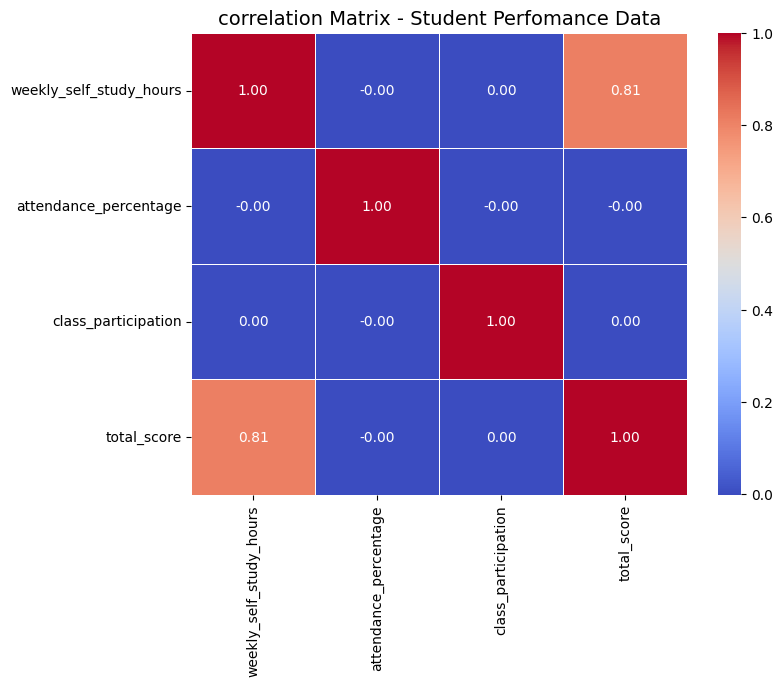

In [11]:
numerical_cols = ['weekly_self_study_hours','attendance_percentage', 'class_participation', 'total_score']
corr_matrix = data[numerical_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('correlation Matrix - Student Perfomance Data', fontsize=14)
plt.show()

## MACHINE LEANING

### TRAIN MODEL

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

In [13]:
X= data[['weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score']]
y_gpa = data['GPA']
y_grade = data['grade']
y_class = data['academic_class']
y_risk = data['dropout_risk']
y_grad = data['graduation_probability']
y_recom = data['recommendation']
print("Training all 6 models")
gpa_model = DecisionTreeRegressor(random_state=42).fit(X, y_gpa)
grad_model = DecisionTreeRegressor(random_state=42).fit(X, y_grad)

grade_model = DecisionTreeClassifier(random_state=42).fit(X, y_grade)
Class_model = DecisionTreeClassifier(random_state=42).fit(X, y_class)
risk_model = DecisionTreeClassifier(random_state=42).fit(X, y_risk)
grade_recom = DecisionTreeClassifier(random_state=42).fit(X, y_recom)
print("All 6 models are now trained effectively")


Training all 6 models
All 6 models are now trained effectively


### TEST MODEL
#####  GRADE PREDICTION MODEL

In [14]:
grade_model = DecisionTreeClassifier(random_state=42)

grade_model.fit(X, y_grade);

#####  CLASS PREDICTION MODEL

In [15]:
class_model = DecisionTreeClassifier(random_state=42)

class_model.fit(X, y_class);

##### RISK LEVEL MODEL

In [16]:
risk_model = DecisionTreeClassifier(random_state=42)

risk_model.fit(X, y_risk);

##### GRADUATION PROBABILITY MODEL

In [17]:
grad_model = DecisionTreeRegressor(random_state=42)

grad_model.fit(X, y_grad);

##### RECOMMENDATION MODEL

In [18]:
recom_model = DecisionTreeClassifier(random_state=42)

recom_model.fit(X, y_recom);

#####  NEW STUDENT RECORD

In [19]:
new_student = [[85, 10, 8, 90]]
#Aattendance_percentage, weekly_self_study_hours, class_participation, total_score

#####  PREDICT GPA

In [20]:
predicted_gpa = gpa_model.predict(new_student)

print(predicted_gpa)

[4.5]


#####  PREDICT GRADE

In [21]:
predicted_grade = grade_model.predict(new_student)

print(predicted_grade)

['A']


##### PREDICT ACADEMIC CLASS

In [22]:
predicted_class = class_model.predict(new_student)

print(predicted_class)

['First Class / Super']


#####  PREDICT RISK LEVEL

In [23]:
predicted_risk = risk_model.predict(new_student)

print(predicted_risk)

['Low']


#####  PREDICT GRADUATION PROBABILITY

In [24]:
predicted_grad = grad_model.predict(new_student)

print(predicted_grad)

[95.]


#####  PREDICT RECOMMENDATION 

In [25]:
predicted_recom = recom_model.predict(new_student)

print(predicted_recom)

['Maintain performance']


#####  DISPLAY ALL RESULT

In [26]:
print("GPA:", predicted_gpa[0])
print("Grade:", predicted_grade[0])
print("Class:", predicted_class[0])
print("Risk:", predicted_risk[0])
print("Graduation Probability:", predicted_grad[0])
print("Recommendation:", predicted_recom[0])

GPA: 4.5
Grade: A
Class: First Class / Super
Risk: Low
Graduation Probability: 95.0
Recommendation: Maintain performance


## ACCURACY & R2

In [27]:
print(f"GPA Model R2: {r2_score(y_gpa, gpa_model.predict(X)) * 100:.2f}%")
print(f"Graduation Probability Model R2: {r2_score(y_grad, grad_model.predict(X)) * 100:.2f}%")

GPA Model R2: 100.00%
Graduation Probability Model R2: 100.00%


In [28]:
print(f"Grade Model Accuracy: {accuracy_score(y_grade, grade_model.predict(X)) * 100:.2f}%")
print(f"Dropout Risk Accuracy: {accuracy_score(y_risk, risk_model.predict(X)) * 100:.2f}%")

Grade Model Accuracy: 100.00%
Dropout Risk Accuracy: 100.00%
